In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the clean dataset
df = pd.read_csv('../data/cleaned_travel_data.csv')

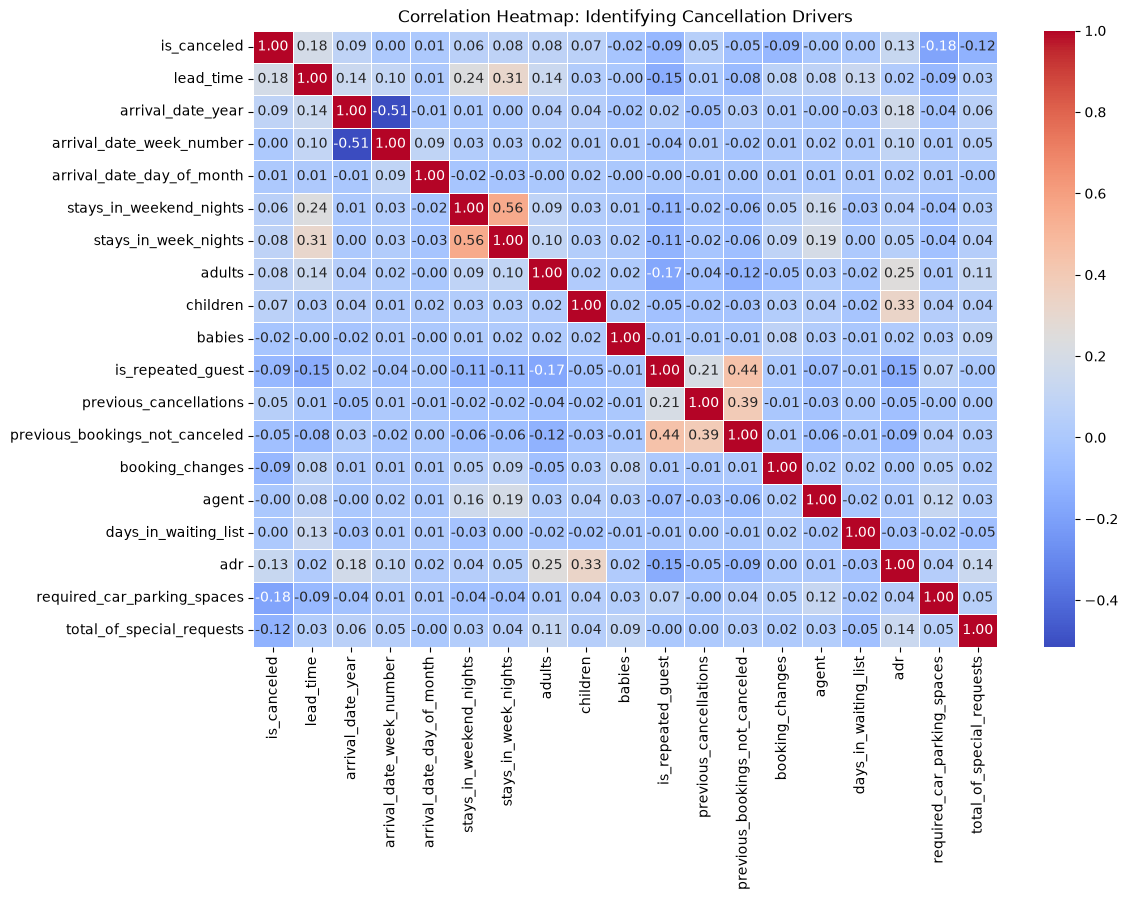

In [2]:
# 1. Filter the dataset to include only numerical columns (correlation requires numbers)
numerical_df = df.select_dtypes(include=['number'])

# 2. Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# 3. Plot the correlation matrix as a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: Identifying Cancellation Drivers')
plt.show()

### Exploratory Data Analysis: Cancellation Drivers (Correlation Matrix)

**Objective:** To identify which numerical features most strongly impact the likelihood of a booking cancellation (`is_canceled`). 

**Statistical Significance & Findings:**
Based on the Pearson correlation heatmap generated above, we can draw the following statistical conclusions regarding churn:

1. **Primary Drivers of Cancellations (Positive Correlation):**
   * The feature `lead_time` shows the strongest positive correlation with cancellations at **0.18**. Additionally, the Average Daily Rate (`adr`) shows a notable positive correlation at **0.13**. 
   * *Business Impact:* This statistically proves that the further out a customer books their room, and the higher the daily room rate, the more likely they are to cancel the reservation. 

2. **Primary Retention Drivers (Negative Correlation):**
   * The feature `required_car_parking_spaces` shows the strongest negative correlation at **-0.18**, followed closely by `total_of_special_requests` at **-0.12**. 
   * *Business Impact:* Customers who register a vehicle for parking or interact more with the hotel prior to arrival (making special requests) are statistically much less likely to cancel.

3. **Insignificant Features:**
   * Variables such as `arrival_date_week_number`, `agent`, and `days_in_waiting_list` showed correlation coefficients at or near **0.00**, indicating they are not statistically significant predictors of churn on their own.

**Next Steps for Modeling:** Features with the highest absolute correlation values—specifically `lead_time`, `adr`, `required_car_parking_spaces`, and `total_of_special_requests`—will serve as the primary foundational inputs when building our predictive classification models in Week 3.